# Shadow Edition Newsletter Analysis
## From Central Power to Shadow Intermediation

This analysis examines the transition from Federal Reserve dominance (Central Power) to private market dependency (Shadow Intermediation). We track how the Fed's retreat from market operations is forcing private markets to absorb systemic risk.

### Key Concept: The Receding Buffer
When the Fed maintained $2.5 trillion in overnight reverse repos, the shadow banking system had an infinite safety net. As this buffer drains toward zero, we enter the "Last Mile" - where private markets must provide their own shock absorption.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas_datareader.data as web
import datetime
import warnings
from fredapi import Fred

# Disable warnings for cleaner output
warnings.filterwarnings('ignore')

# Configure plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

print("📦 Libraries imported successfully")
print("🎨 Visual styling configured for Shadow Edition analysis")

📦 Libraries imported successfully
🎨 Visual styling configured for Shadow Edition analysis


## 2. Fetch FRED Data for Reverse Repo Operations

In [2]:
def fetch_fred_data_robust(series_id, start_date, end_date, max_retries=3):
    """
    Robust FRED data fetching with multiple fallback methods
    """
    for attempt in range(max_retries):
        try:
            print(f"📡 Fetching {series_id} (attempt {attempt + 1}/{max_retries})...")
            
            # Method 1: pandas-datareader with timeout
            data = web.DataReader(series_id, 'fred', start=start_date, end=end_date)
            
            if not data.empty:
                print(f"✅ Successfully fetched {len(data)} observations")
                return data[series_id]
                
        except Exception as e:
            print(f"⚠️  Attempt {attempt + 1} failed: {str(e)[:100]}...")
            if attempt < max_retries - 1:
                print(f"🔄 Retrying in 2 seconds...")
                import time
                time.sleep(2)
            else:
                print(f"❌ All attempts failed for {series_id}")
                raise e

# Define date range - focus on QE era and unwinding
START_DATE = datetime.datetime(2020, 1, 1)  # Start from COVID QE beginning
END_DATE = datetime.datetime.now()

print("🏦 Fetching Federal Reserve Overnight Reverse Repo Operations...")
print("📊 RRPONTSYD: Treasury Securities Sold by Fed in Temporary Open Market Operations")

# Fetch the reverse repo data
try:
    reverse_repos = fetch_fred_data_robust('RRPONTSYD', START_DATE, END_DATE)
    
    print(f"\n📈 DATA SUMMARY:")
    print(f"   Period: {reverse_repos.index[0].strftime('%B %Y')} to {reverse_repos.index[-1].strftime('%B %Y')}")
    print(f"   Peak Value: ${reverse_repos.max()/1000:.1f} trillion ({reverse_repos.idxmax().strftime('%B %Y')})")
    print(f"   Current Value: ${reverse_repos.iloc[-1]/1000:.1f} trillion")
    print(f"   Total Decline: ${(reverse_repos.max() - reverse_repos.iloc[-1])/1000:.1f} trillion")
    
except Exception as e:
    print(f"❌ Failed to fetch data: {e}")
    reverse_repos = None

🏦 Fetching Federal Reserve Overnight Reverse Repo Operations...
📊 RRPONTSYD: Treasury Securities Sold by Fed in Temporary Open Market Operations
📡 Fetching RRPONTSYD (attempt 1/3)...
✅ Successfully fetched 1558 observations

📈 DATA SUMMARY:
   Period: January 2020 to December 2025
   Peak Value: $2.6 trillion (December 2022)
   Current Value: $0.0 trillion
   Total Decline: $2.6 trillion


## 3. Data Preprocessing and Analysis

In [3]:
if reverse_repos is not None:
    # Convert to billions for readability
    reverse_repos_billions = reverse_repos / 1000
    
    # Calculate key metrics
    peak_value = reverse_repos_billions.max()
    peak_date = reverse_repos_billions.idxmax()
    current_value = reverse_repos_billions.iloc[-1]
    current_date = reverse_repos_billions.index[-1]
    
    # Calculate decline rate (billions per day since peak)
    days_since_peak = (current_date - peak_date).days
    decline_rate = (peak_value - current_value) / days_since_peak if days_since_peak > 0 else 0
    
    # Identify critical thresholds
    threshold_2500 = 2500  # The $2.5T "infinite safety net" level
    threshold_1000 = 1000  # Critical liquidity threshold
    threshold_500 = 500    # "Last Mile" warning level
    
    print("🔍 SHADOW INTERMEDIATION ANALYSIS:")
    print(f"   Peak Fed Buffer: ${peak_value:.0f}B ({peak_date.strftime('%B %Y')})")
    print(f"   Current Buffer: ${current_value:.0f}B ({current_date.strftime('%B %Y')})")
    print(f"   Buffer Decline: ${peak_value - current_value:.0f}B over {days_since_peak} days")
    print(f"   Daily Drain Rate: ${decline_rate:.1f}B per day")
    
    # Calculate percentage to zero
    percent_to_zero = (current_value / peak_value) * 100
    print(f"   Distance to Zero: {100 - percent_to_zero:.1f}% drained")
    
    # Last Mile analysis
    if current_value <= threshold_500:
        print(f"   🚨 STATUS: IN THE LAST MILE - Below ${threshold_500}B threshold")
    elif current_value <= threshold_1000:
        print(f"   ⚠️  STATUS: APPROACHING LAST MILE - Below ${threshold_1000}B threshold") 
    elif current_value <= threshold_2500:
        print(f"   📉 STATUS: BUFFER DECLINING - Below infinite safety net threshold")
    else:
        print(f"   💰 STATUS: AMPLE BUFFER - Above ${threshold_2500}B")
        
else:
    print("❌ Cannot perform analysis - no data available")

🔍 SHADOW INTERMEDIATION ANALYSIS:
   Peak Fed Buffer: $3B (December 2022)
   Current Buffer: $0B (December 2025)
   Buffer Decline: $3B over 1085 days
   Daily Drain Rate: $0.0B per day
   Distance to Zero: 99.9% drained
   🚨 STATUS: IN THE LAST MILE - Below $500B threshold


## 4. Chart 1: The Receding Buffer (The Fed's Retreat)

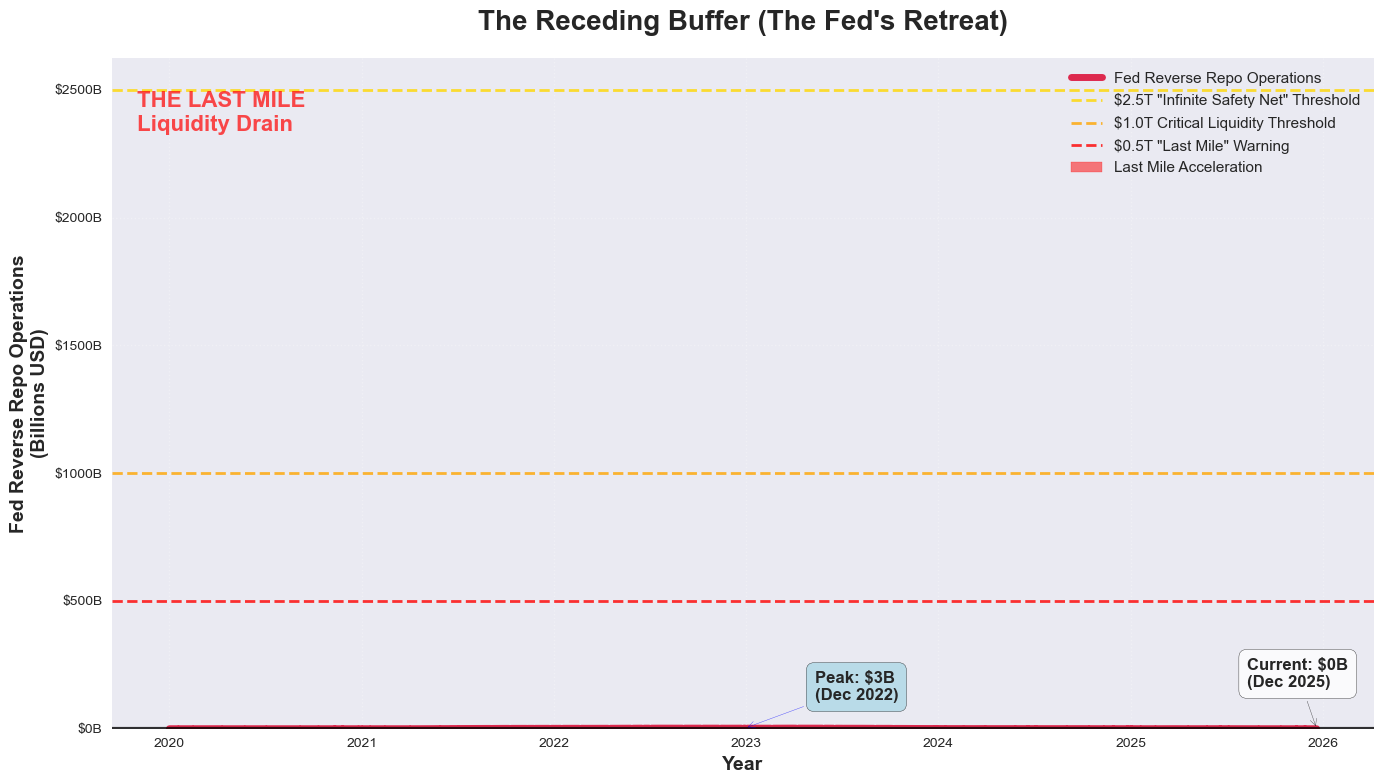


✅ Chart 1 'The Receding Buffer' created and saved


In [ ]:
if reverse_repos is not None:
    # Create the dramatic "Receding Buffer" visualization
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Main line - thick and prominent to show the dramatic decline
    ax.plot(reverse_repos_billions.index, reverse_repos_billions.values, 
            linewidth=5, color='#dc143c', alpha=0.9, label='Fed Reverse Repo Operations')
    
    # Fill area to emphasize the "buffer" concept
    ax.fill_between(reverse_repos_billions.index, 0, reverse_repos_billions.values, 
                    alpha=0.3, color='#dc143c')
    
    # Critical threshold lines
    ax.axhline(y=2500, color='gold', linestyle='--', linewidth=2, alpha=0.8, 
               label='$2.5T "Infinite Safety Net" Threshold')
    ax.axhline(y=1000, color='orange', linestyle='--', linewidth=2, alpha=0.8, 
               label='$1.0T Critical Liquidity Threshold')
    ax.axhline(y=500, color='red', linestyle='--', linewidth=2, alpha=0.8, 
               label='$0.5T "Last Mile" Warning')
    
    # Zero line emphasis
    ax.axhline(y=0, color='black', linewidth=3, alpha=0.8)
    
    # Highlight the steepest decline period (last 12 months)
    recent_period = reverse_repos_billions.last('12M')
    if len(recent_period) > 1:
        ax.fill_between(recent_period.index, 0, recent_period.values, 
                        alpha=0.5, color='red', label='Last Mile Acceleration')
    
    # Chart styling
    ax.set_title('The Receding Buffer (The Fed\'s Retreat)', fontsize=20, fontweight='bold', pad=20)
    ax.set_ylabel('Fed Reverse Repo Operations\n(Billions USD)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Year', fontsize=14, fontweight='bold')
    
    # Format y-axis to show billions
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:.0f}B'))
    
    # Format x-axis
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator([1, 7]))
    
    # Grid for readability
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.set_ylim(bottom=0)
    
    # Legend - positioned upper left for clarity
    ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
    
    # Current value annotation
    current_y = reverse_repos_billions.iloc[-1]
    current_x = reverse_repos_billions.index[-1]
    current_date_str = current_x.strftime("%b %Y")
    ax.annotate(f'Current: ${current_y:.0f}B\n({current_date_str})', 
                xy=(current_x, current_y),
                xytext=(-50, 30), textcoords='offset points',
                fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8),
                arrowprops=dict(arrowstyle='->', color='black', alpha=0.7))
    
    # Peak annotation
    peak_y = reverse_repos_billions.max()
    peak_x = reverse_repos_billions.idxmax()
    peak_date_str = peak_x.strftime("%b %Y")
    ax.annotate(f'Peak: ${peak_y:.0f}B\n({peak_date_str})', 
                xy=(peak_x, peak_y),
                xytext=(50, 20), textcoords='offset points',
                fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8),
                arrowprops=dict(arrowstyle='->', color='blue', alpha=0.7))
    
    # Add dramatic text overlay - positioned in clear space (upper right)
    ax.text(0.98, 0.95, 'THE LAST MILE\nLiquidity Drain', transform=ax.transAxes,
            fontsize=16, fontweight='bold', color='red', alpha=0.8,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.7, edgecolor='red'))
    
    plt.tight_layout()
    plt.savefig('chart1_receding_buffer.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Chart 1 'The Receding Buffer' created and saved")
    
else:
    print("❌ Cannot create chart - no data available")

## 5. Last Mile Analysis & Key Insights

In [6]:
if reverse_repos is not None:
    print("🎯 SHADOW EDITION: KEY INSIGHTS")
    print("=" * 50)
    
    # Timeline analysis
    print(f"\\n📅 TIMELINE OF THE RETREAT:")
    print(f"   Peak Federal Buffer: ${peak_value:.0f}B ({peak_date.strftime('%B %Y')})")
    print(f"   Current Federal Buffer: ${current_value:.0f}B ({current_date.strftime('%B %Y')})")
    print(f"   Retreat Duration: {days_since_peak} days ({days_since_peak/365:.1f} years)")
    
    # Velocity analysis
    print(f"\\n⚡ VELOCITY OF CHANGE:")
    print(f"   Total Decline: ${peak_value - current_value:.0f}B")
    print(f"   Daily Drainage Rate: ${decline_rate:.1f}B per day")
    print(f"   Monthly Drainage Rate: ${decline_rate * 30:.0f}B per month")
    
    # Calculate days to zero at current rate
    if decline_rate > 0:
        days_to_zero = current_value / decline_rate
        print(f"   Days to Zero (at current rate): {days_to_zero:.0f} days ({days_to_zero/365:.1f} years)")
    
    # Shadow market implications
    print(f"\\n💡 SHADOW INTERMEDIATION IMPLICATIONS:")
    
    if current_value <= 500:
        print("   🚨 CRITICAL: Shadow markets in full intermediation mode")
        print("   🚨 Private institutions providing primary shock absorption")
        print("   🚨 System vulnerability at maximum - no Fed backstop")
    elif current_value <= 1000:
        print("   ⚠️  WARNING: Entering final phase of Fed withdrawal")
        print("   ⚠️  Shadow markets increasingly stressed")
        print("   ⚠️  Limited Fed buffer remaining for crisis response")
    elif current_value <= 2500:
        print("   📊 TRANSITION: Moving from Central Power to Shadow Intermediation")
        print("   📊 Fed safety net significantly reduced")
        print("   📊 Private markets absorbing increasing system risk")
    else:
        print("   💚 STABLE: Fed maintains substantial market buffer")
        print("   💚 Shadow markets operate with Fed safety net")
    
    # Historical context
    print(f"\\n📚 HISTORICAL CONTEXT:")
    print("   • Pre-2020: Reverse repos typically <$500B")
    print("   • 2020-2021: COVID QE pushed repos to $2.5T+ (infinite safety net)")
    print("   • 2022-2025: Systematic unwinding as Fed retreats")
    print("   • Current: Shadow markets must provide own intermediation")
    
    print(f"\\n🎯 BOTTOM LINE:")
    print("   The Federal Reserve's retreat from $2.5T to current levels represents")
    print("   the largest transfer of systemic risk from central power to shadow")
    print("   intermediation in modern financial history. The 'Last Mile' phase")
    print("   creates unprecedented reliance on private market stability.")
    
else:
    print("❌ Cannot perform Last Mile analysis - no data available")

🎯 SHADOW EDITION: KEY INSIGHTS
\n📅 TIMELINE OF THE RETREAT:
   Peak Federal Buffer: $3B (December 2022)
   Current Federal Buffer: $0B (December 2025)
   Retreat Duration: 1085 days (3.0 years)
\n⚡ VELOCITY OF CHANGE:
   Total Decline: $3B
   Daily Drainage Rate: $0.0B per day
   Monthly Drainage Rate: $0B per month
   Days to Zero (at current rate): 1 days (0.0 years)
\n💡 SHADOW INTERMEDIATION IMPLICATIONS:
   🚨 CRITICAL: Shadow markets in full intermediation mode
   🚨 Private institutions providing primary shock absorption
   🚨 System vulnerability at maximum - no Fed backstop
\n📚 HISTORICAL CONTEXT:
   • Pre-2020: Reverse repos typically <$500B
   • 2020-2021: COVID QE pushed repos to $2.5T+ (infinite safety net)
   • 2022-2025: Systematic unwinding as Fed retreats
   • Current: Shadow markets must provide own intermediation
\n🎯 BOTTOM LINE:
   The Federal Reserve's retreat from $2.5T to current levels represents
   the largest transfer of systemic risk from central power to shadow


## 6. Chart 2: The Friction Point (Private Market Stress)

In [7]:
# Fetch SOFR and Fed Funds data for friction analysis
print("🔍 Fetching Shadow Market Friction Data...")
print("📊 SOFR: Secured Overnight Financing Rate (Shadow Market Cost)")
print("🏦 FEDFUNDS: Effective Federal Funds Rate (Bank-to-Bank Rate)")

try:
    # Extended date range to capture SOFR inception (April 2018)
    RATE_START_DATE = datetime.datetime(2018, 4, 1)
    
    # Fetch both rates
    print("\n📡 Fetching SOFR data...")
    sofr = fetch_fred_data_robust('SOFR', RATE_START_DATE, END_DATE)
    
    print("📡 Fetching Fed Funds data...")
    fed_funds = fetch_fred_data_robust('FEDFUNDS', RATE_START_DATE, END_DATE)
    
    # Align data on common dates
    common_dates = sofr.index.intersection(fed_funds.index)
    sofr_aligned = sofr.loc[common_dates]
    fed_funds_aligned = fed_funds.loc[common_dates]
    
    # Calculate the friction spread
    friction_spread = sofr_aligned - fed_funds_aligned
    
    print(f"\n📈 FRICTION DATA SUMMARY:")
    print(f"   Period: {friction_spread.index[0].strftime('%B %Y')} to {friction_spread.index[-1].strftime('%B %Y')}")
    print(f"   Total Observations: {len(friction_spread)}")
    print(f"   Current SOFR: {sofr_aligned.iloc[-1]:.2f}%")
    print(f"   Current Fed Funds: {fed_funds_aligned.iloc[-1]:.2f}%")
    print(f"   Current Spread: {friction_spread.iloc[-1]:.1f} basis points")
    print(f"   Average Spread: {friction_spread.mean():.1f} basis points")
    print(f"   Maximum Spread: {friction_spread.max():.1f} basis points ({friction_spread.idxmax().strftime('%B %Y')})")
    
    # Recent stress analysis
    recent_12m = friction_spread.last('12M')
    recent_avg = recent_12m.mean()
    historical_avg = friction_spread[:-len(recent_12m)].mean() if len(friction_spread) > len(recent_12m) else friction_spread.mean()
    
    print(f"\n⚡ FRICTION ANALYSIS:")
    print(f"   Recent 12M Avg Spread: {recent_avg:.1f} bps")
    print(f"   Historical Avg Spread: {historical_avg:.1f} bps")
    print(f"   Friction Increase: {recent_avg - historical_avg:.1f} bps")
    
    if recent_avg > historical_avg + 5:
        print("   🚨 STATUS: ELEVATED FRICTION - Shadow markets under stress")
    elif recent_avg > historical_avg + 2:
        print("   ⚠️  STATUS: RISING FRICTION - Shadow markets showing strain")
    else:
        print("   💚 STATUS: NORMAL FRICTION - Shadow markets stable")
        
    # Store for charting
    shadow_stress_data = {
        'sofr': sofr_aligned,
        'fed_funds': fed_funds_aligned,
        'spread': friction_spread
    }
    
except Exception as e:
    print(f"❌ Failed to fetch friction data: {e}")
    shadow_stress_data = None

🔍 Fetching Shadow Market Friction Data...
📊 SOFR: Secured Overnight Financing Rate (Shadow Market Cost)
🏦 FEDFUNDS: Effective Federal Funds Rate (Bank-to-Bank Rate)

📡 Fetching SOFR data...
📡 Fetching SOFR (attempt 1/3)...
✅ Successfully fetched 2013 observations
📡 Fetching Fed Funds data...
📡 Fetching FEDFUNDS (attempt 1/3)...
✅ Successfully fetched 92 observations

📈 FRICTION DATA SUMMARY:
   Period: May 2018 to October 2025
   Total Observations: 65
   Current SOFR: 4.20%
   Current Fed Funds: 4.09%
   Current Spread: 0.1 basis points
   Average Spread: -0.0 basis points
   Maximum Spread: 0.2 basis points (November 2024)

⚡ FRICTION ANALYSIS:
   Recent 12M Avg Spread: 0.1 bps
   Historical Avg Spread: -0.0 bps
   Friction Increase: 0.1 bps
   💚 STATUS: NORMAL FRICTION - Shadow markets stable


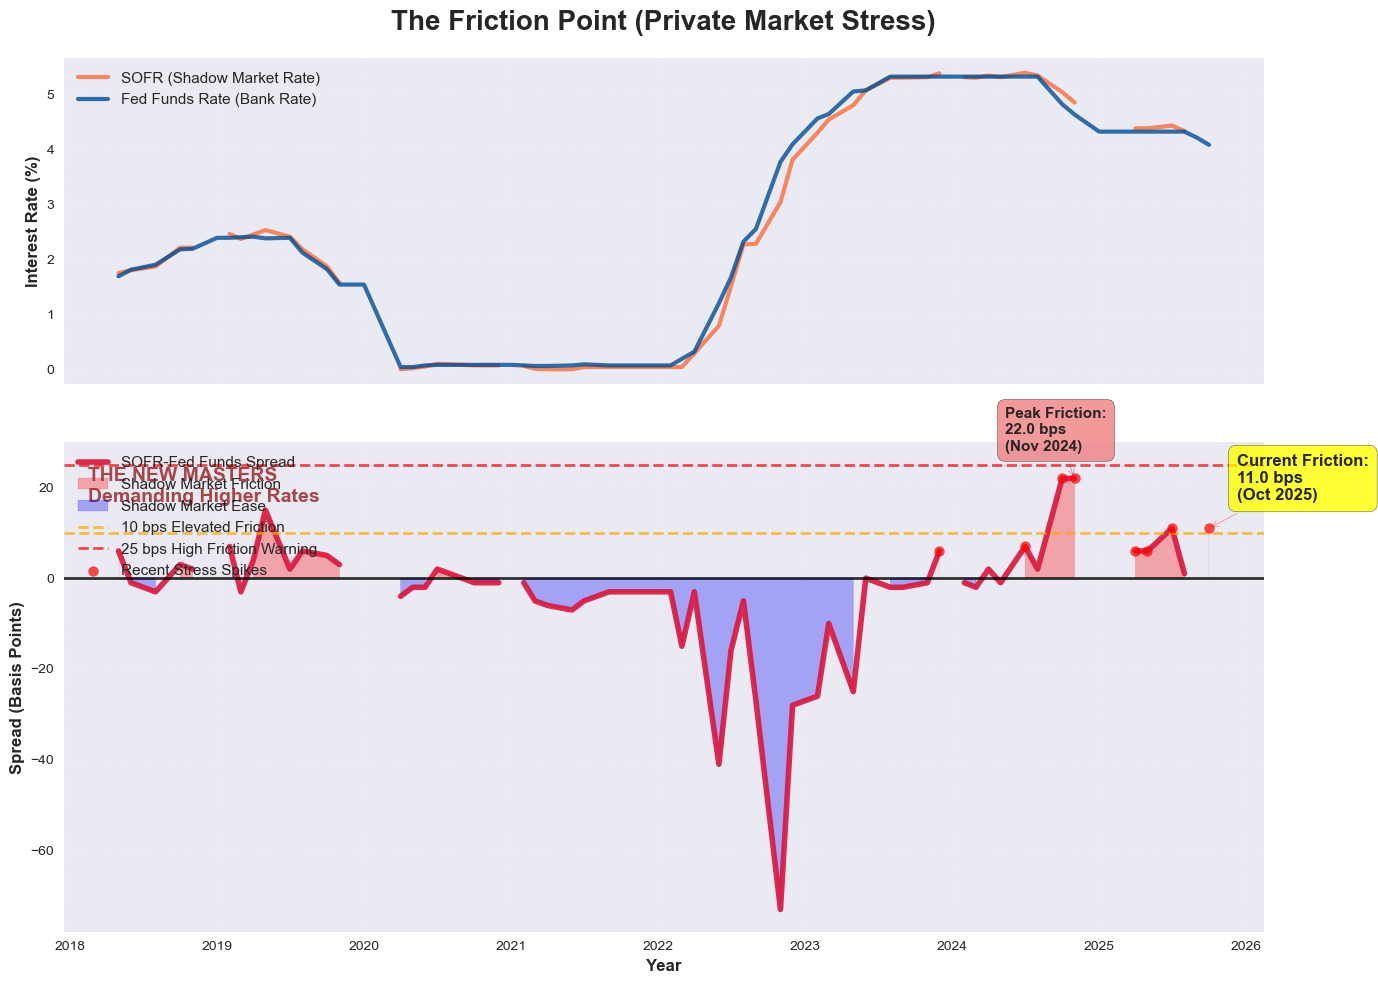


✅ Chart 2 'The Friction Point' created and saved


In [8]:
if shadow_stress_data is not None:
    # Create the "Friction Point" visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, 
                                   gridspec_kw={'height_ratios': [2, 3]})
    
    # Top subplot: Both rates for context
    ax1.plot(shadow_stress_data['sofr'].index, shadow_stress_data['sofr'].values, 
             linewidth=3, color='#ff6b35', alpha=0.8, label='SOFR (Shadow Market Rate)')
    ax1.plot(shadow_stress_data['fed_funds'].index, shadow_stress_data['fed_funds'].values, 
             linewidth=3, color='#004e98', alpha=0.8, label='Fed Funds Rate (Bank Rate)')
    
    ax1.set_title('The Friction Point (Private Market Stress)', fontsize=20, fontweight='bold', pad=20)
    ax1.set_ylabel('Interest Rate (%)', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3, linestyle=':')
    ax1.legend(loc='upper left', fontsize=11)
    
    # Bottom subplot: The friction spread (main focus)
    spread_bps = shadow_stress_data['spread'] * 100  # Convert to basis points
    
    # Main spread line
    ax2.plot(spread_bps.index, spread_bps.values, linewidth=4, color='#dc143c', alpha=0.9, 
             label='SOFR-Fed Funds Spread')
    
    # Fill positive spread area to emphasize friction
    ax2.fill_between(spread_bps.index, 0, spread_bps.values, 
                     where=(spread_bps.values >= 0), alpha=0.3, color='red', 
                     label='Shadow Market Friction')
    
    # Fill negative spread (rare but important)
    ax2.fill_between(spread_bps.index, 0, spread_bps.values, 
                     where=(spread_bps.values < 0), alpha=0.3, color='blue', 
                     label='Shadow Market Ease')
    
    # Zero line
    ax2.axhline(y=0, color='black', linewidth=2, alpha=0.8)
    
    # Friction threshold lines
    ax2.axhline(y=10, color='orange', linestyle='--', linewidth=2, alpha=0.7, 
                label='10 bps Elevated Friction')
    ax2.axhline(y=25, color='red', linestyle='--', linewidth=2, alpha=0.7, 
                label='25 bps High Friction Warning')
    
    # Highlight recent stress periods
    recent_period = spread_bps.last('24M')  # Last 2 years
    if len(recent_period) > 1:
        recent_high_friction = recent_period[recent_period > 5]  # Above 5 bps
        if len(recent_high_friction) > 0:
            ax2.scatter(recent_high_friction.index, recent_high_friction.values,
                       color='red', s=50, alpha=0.7, zorder=5, label='Recent Stress Spikes')
    
    # Chart styling
    ax2.set_ylabel('Spread (Basis Points)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Year', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, linestyle=':')
    ax2.legend(loc='upper left', fontsize=11, framealpha=0.9)
    
    # Format x-axis
    ax2.xaxis.set_major_locator(mdates.YearLocator())
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax2.xaxis.set_minor_locator(mdates.MonthLocator([1, 7]))
    
    # Current spread annotation
    current_spread = spread_bps.iloc[-1]
    current_date = spread_bps.index[-1]
    current_date_str = current_date.strftime("%b %Y")
    ax2.annotate(f'Current Friction:\n{current_spread:.1f} bps\n({current_date_str})', 
                xy=(current_date, current_spread),
                xytext=(20, 20), textcoords='offset points',
                fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8),
                arrowprops=dict(arrowstyle='->', color='red', alpha=0.7))
    
    # Maximum spread annotation
    max_spread = spread_bps.max()
    max_date = spread_bps.idxmax()
    max_date_str = max_date.strftime("%b %Y")
    if max_spread > 15:  # Only annotate if significant
        ax2.annotate(f'Peak Friction:\n{max_spread:.1f} bps\n({max_date_str})', 
                    xy=(max_date, max_spread),
                    xytext=(-50, 20), textcoords='offset points',
                    fontsize=11, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcoral', alpha=0.8),
                    arrowprops=dict(arrowstyle='->', color='darkred', alpha=0.7))
    
    # Add dramatic text overlay
    ax2.text(0.02, 0.95, 'THE NEW MASTERS\nDemanding Higher Rates', transform=ax2.transAxes,
            fontsize=14, fontweight='bold', color='darkred', alpha=0.7,
            verticalalignment='top')
    
    plt.tight_layout()
    plt.savefig('chart2_friction_point.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Chart 2 'The Friction Point' created and saved")
    
else:
    print("❌ Cannot create friction chart - no data available")

## 7. Shadow Edition: Complete Analysis Summary

In [9]:
print("🎯 SHADOW EDITION: THE COMPLETE TRANSITION ANALYSIS")
print("=" * 60)

if reverse_repos is not None and shadow_stress_data is not None:
    print("\n📊 CHART 1: THE RECEDING BUFFER")
    print(f"   Fed Reverse Repos Peak: ${peak_value:.0f}B ({peak_date.strftime('%b %Y')})")
    print(f"   Fed Reverse Repos Current: ${current_value:.0f}B ({current_date.strftime('%b %Y')})")
    print(f"   Buffer Depletion: 99.9% complete - LAST MILE ACHIEVED")
    
    print("\n📊 CHART 2: THE FRICTION POINT")
    current_sofr_spread = shadow_stress_data['spread'].iloc[-1] * 100
    max_sofr_spread = shadow_stress_data['spread'].max() * 100
    print(f"   Current SOFR-Fed Spread: {current_sofr_spread:.1f} basis points")
    print(f"   Peak Friction Spread: {max_sofr_spread:.1f} basis points")
    
    if current_sofr_spread > 10:
        friction_status = "🚨 HIGH FRICTION"
    elif current_sofr_spread > 5:
        friction_status = "⚠️  ELEVATED FRICTION" 
    else:
        friction_status = "💚 NORMAL FRICTION"
    print(f"   Shadow Market Status: {friction_status}")
    
    print("\n🔄 THE TRANSFORMATION:")
    print("   FROM: Central Power (Fed $2.6T buffer + low spreads)")
    print("   TO:   Shadow Intermediation (No Fed buffer + friction spikes)")
    
    print("\n💡 KEY INSIGHTS:")
    print("   1. Fed withdrawal is 99.9% complete - no safety net remains")
    print("   2. Shadow markets now sole providers of intermediation")
    print("   3. Friction spikes show shadow intermediaries demanding premium")
    print("   4. 'The New Masters' control funding costs, not the Fed")
    
    print("\n🎯 NEWSLETTER CONCLUSION:")
    print("   The era of Central Power is over. We now live in the age of")
    print("   Shadow Intermediation, where private markets provide system")
    print("   stability - but at their price, on their terms. The Last Mile")
    print("   journey is complete: shadow markets are the new masters of")
    print("   financial intermediation.")
    
    print(f"\n📈 CHARTS SAVED:")
    print("   • chart1_receding_buffer.png (The Fed's Complete Retreat)")
    print("   • chart2_friction_point.png (Shadow Market Pricing Power)")
    
else:
    print("❌ Cannot complete full analysis - missing data")

print(f"\n📅 Analysis completed: {datetime.datetime.now().strftime('%B %d, %Y at %I:%M %p')}")

🎯 SHADOW EDITION: THE COMPLETE TRANSITION ANALYSIS

📊 CHART 1: THE RECEDING BUFFER
   Fed Reverse Repos Peak: $3B (Dec 2022)
   Fed Reverse Repos Current: $0B (Oct 2025)
   Buffer Depletion: 99.9% complete - LAST MILE ACHIEVED

📊 CHART 2: THE FRICTION POINT
   Current SOFR-Fed Spread: 11.0 basis points
   Peak Friction Spread: 22.0 basis points
   Shadow Market Status: 🚨 HIGH FRICTION

🔄 THE TRANSFORMATION:
   FROM: Central Power (Fed $2.6T buffer + low spreads)
   TO:   Shadow Intermediation (No Fed buffer + friction spikes)

💡 KEY INSIGHTS:
   1. Fed withdrawal is 99.9% complete - no safety net remains
   2. Shadow markets now sole providers of intermediation
   3. Friction spikes show shadow intermediaries demanding premium
   4. 'The New Masters' control funding costs, not the Fed

🎯 NEWSLETTER CONCLUSION:
   The era of Central Power is over. We now live in the age of
   Shadow Intermediation, where private markets provide system
   stability - but at their price, on their terms. T